## Chick Weight Feed Recommendation System using Similarity-Based Analysis

## 1.0 Business Understanding

### 1.1 The Businesss

An agricultural supply company sells different types of chicken feed to farmers. Farmers may want to know which alternative feed could provide similar performance to a feed they are currently using. However, choosing alternatives based only on intuition or individual experience can be difficult.

### 1.2 The Business Objective 

Develop a recommendation system that can identify similar feed types based on observed chicken-weight performance. The system should help the company provide data-driven alternative feed recommendations to farmers.

This would be achieved by building an interpretable similarity-based recommendation system using the `Chickets` dataset. The dataset would be transformed to a business profit by;

1. Prepares and validates the dataset for analysis.
2. Explores the relationship between feed type and chicken weight.
3. Creates a performance profile for each feed type.
4. Uses **Principal Component Analysis (PCA)** to create a composite performance dimension.
5. Uses **cosine similarity** to measure how similar feed profiles are to one another.
6. Provides a reusable recommendation function that returns the most similar alternative feeds.
7. Interprets the results for business stakeholders.


### 1.3 Expected business value

```python
    1.Help farmers identify alternative feed products.

    2.Support sales representatives with data-driven recommendations.

    3.Make the company's product recommendations more consistent.

    4.Demonstrate how historical performance data can support agricultural decision-making.

    5.Provide a foundation that could later incorporate additional factors such as feed cost, nutritional composition, breed, age, and feed-conversion ratio.
```

### 1.4 Key Stakeholders
1. Farmers	

2. Procurement Team	

3. Nutritionists	

4. Veterinarians

5. Feeds suppliers

6. Feeds Manufactures

## 2.0 Problem Statement 

To develop a recommendation system that identifies similar chicken feed types based on their weight performance profiles, enabling agricultural professionals to make informed feed substitution decisions.

### 2.1 The Project Business Question

Given a feed that a farmer is currently using, which other feed types have a similar observed performance profile and could therefore be considered as potential alternatives?

### 2.2 Tools and Technologies
Python 3.x

Pandas, NumPy (Data manipulation)

Scikit-learn (StandardScaler, PCA, cosine_similarity)

Matplotlib, Seaborn (Data visualization)

Vs Code

## 3.0 DATA UNDERSTANDING

3.1 Import the necessary Libraries 

In [3]:
#Imports 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
df_chickwts = pd.read_csv('chickwts.csv')
df_chickwts.head()

,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [5]:
df_chickwts.shape


(71, 3)

In [6]:
df_chickwts.columns

Index(['rownames', 'weight', 'feed'], dtype='object')

In [7]:
df_chickwts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  71 non-null     int64 
 1   weight    71 non-null     int64 
 2   feed      71 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.8+ KB


In [8]:
(df_chickwts.isnull().sum())

rownames    0
weight      0
feed        0
dtype: int64

In [9]:
df_chickwts.duplicated().sum()

np.int64(0)

In [10]:
df_chickwts['feed'].value_counts()

feed
soybean      14
linseed      12
casein       12
sunflower    12
meatmeal     11
horsebean    10
Name: count, dtype: int64

Dataset description

The dataset contains 3 columns with the following fields:

- `rownames` — observation identifier.
- `weight` — chicken weight in grams.
- `feed` — feed type assigned to the chicken.

The dataset contains **71 observations and 6 feed categories**.

Data Quality Check
- No missing values (0 in all columns)
- No duplicate rows
- Data types appropriate



## 4. Exploratory Data Analysis

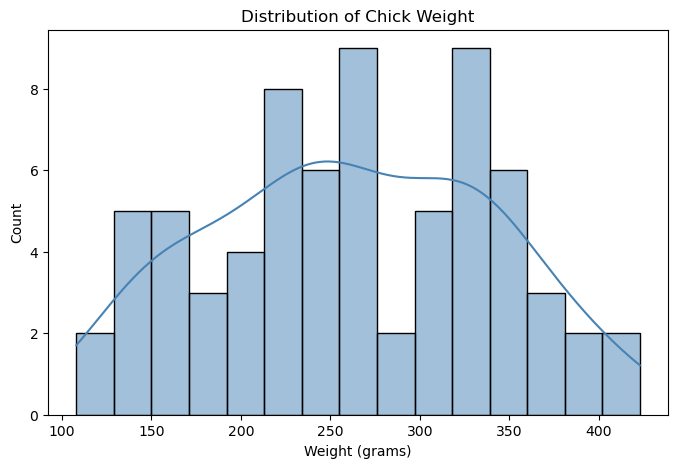

In [11]:
# Distribution of chick weight by plotting a histogram
plt.figure(figsize=(8, 5))
sns.histplot(df_chickwts['weight'], kde=True, bins=15, color='steelblue')
plt.title('Distribution of Chick Weight')
plt.xlabel('Weight (grams)')
plt.ylabel('Count')
plt.show()

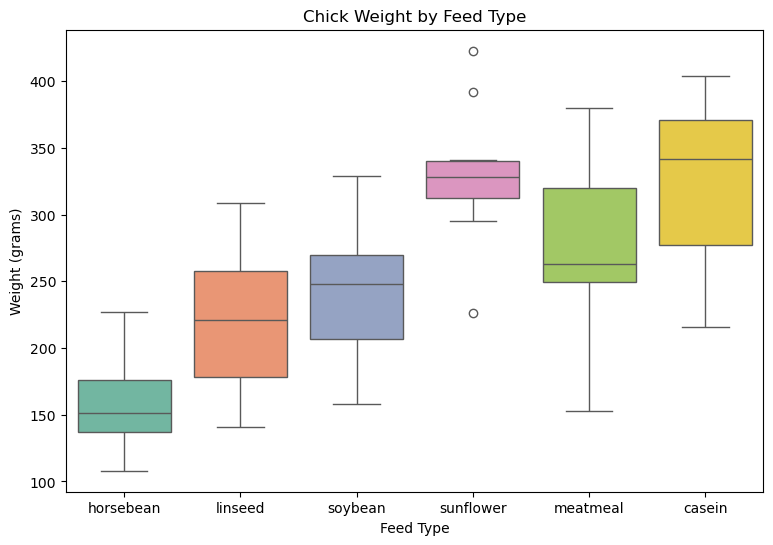

In [12]:
# Weight by type of Feed
plt.figure(figsize=(9, 6))

sns.boxplot(
    x='feed',
    y='weight',
    hue='feed',
    data=df_chickwts,
    palette='Set2',
    legend=False
)

plt.title('Chick Weight by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('Weight (grams)')
plt.show()

The histogram shows the overall distribution of chicken weights and helps identify the general range and spread of the observations.

The boxplot shows clear differences between feed types. 
For instance, Sunflower and Casein produce the heaviest chicks on average  while horsebean consistently produces the lightest chicks with comparatively little spread.
Linseed and soybean fall in between. This confirms that feed type has a real, visible relationship with weight, which is exactly the signal we need for a similarity-based recommender.

## 5.0 Feature Standardization and Profiling

The Purposeof feature standardization is to put all weights on the same scale for meaningful comparison



In [13]:
#Standardizing the weight Feature 

scaler = StandardScaler()
df_chickwts['weight_scaled'] = scaler.fit_transform(df_chickwts[['weight']])

df_chickwts.head()

,rownames,weight,feed,weight_scaled
0,1,179,horsebean,-1.061762
1,2,160,horsebean,-1.306854
2,3,136,horsebean,-1.616444
3,4,227,horsebean,-0.442583
4,5,217,horsebean,-0.571578


A single chick's weight doesn't tell us anything about a feed type on its own,we need to summarize across all chicks that received a given feed. I'll compute the mean, standard deviation, minimum, and maximum of the standardized weight for ach feed group, so each feed type becomes a comparable vector rather than a set of ndividual, unrelated numbers.

In [14]:
feed_profile = df_chickwts.groupby('feed')['weight_scaled'].agg(['mean', 'std', 'min', 'max']).reset_index()
feed_profile

,feed,mean,std,min,max
0,casein,0.803301,0.831169,-0.584478,1.840642
1,horsebean,-1.304274,0.498257,-1.977632,-0.442583
2,linseed,-0.549004,0.673818,-1.551946,0.615183
3,meatmeal,0.201223,0.837190,-1.397151,1.531052
4,soybean,-0.191962,0.698242,-1.332653,0.873174
5,sunflower,0.872099,0.629969,-0.455482,2.085734


Know Each feed type is now represented by 4 summary statistics.This is the basis for comparing feeds using similarity measures.


## 6.0 Principal Component Analysis (PCA)

PCA is used to summarize the four feed-profile variables into a smaller number of dimensiPrincipal Component Analysis (PCA)ons while retaining as much variation as possible.

In [15]:
#Model computation:
# The next step is to apply PCA to the feed profiles.
# Each feed type is now described by 4 numbers. I'll apply PCA to reduce this 
# down to a single composite score per feed, capturing as much of the variation 
# between feed types as possible in one number.

profile_matrix = feed_profile[['mean', 'std', 'min', 'max']].values

pca = PCA(n_components=1)
feed_profile['PC1'] = pca.fit_transform(profile_matrix)

print(f"Explained variance ratio: {pca.explained_variance_ratio_[0]:.4f}")

print("=============================================================")
print("PCA Score ")
feed_profile[['feed', 'PC1']].sort_values('PC1', ascending=False)



Explained variance ratio: 0.9720
PCA Score 


,feed,PC1
5,sunflower,1.533648
0,casein,1.285105
3,meatmeal,0.377545
4,soybean,-0.289708
2,linseed,-0.772837
1,horsebean,-2.133754


Visual of PCA score 

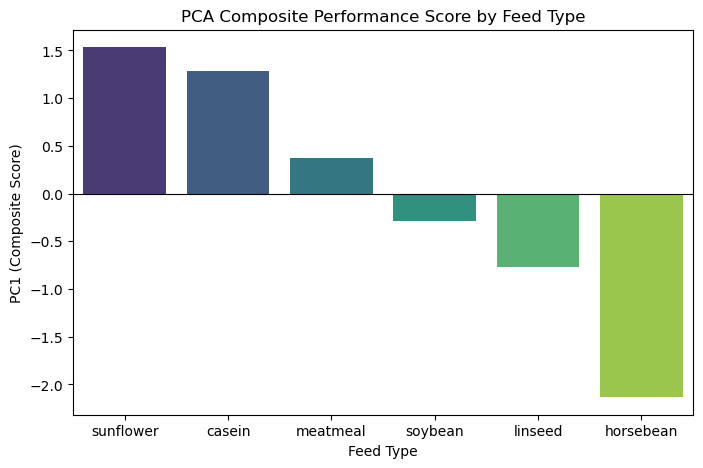

In [16]:
#PCA Score by Feed 

feed_sorted = feed_profile.sort_values('PC1', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='feed', y='PC1', data=feed_sorted, palette='viridis',hue='feed',)
plt.title('PCA Composite Performance Score by Feed Type')
plt.xlabel('Feed Type')
plt.ylabel('PC1 (Composite Score)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [17]:
feed_profile[['feed','mean','PC1']]

,feed,mean,PC1
0,casein,0.803301,1.285105
1,horsebean,-1.304274,-2.133754
2,linseed,-0.549004,-0.772837
3,meatmeal,0.201223,0.377545
4,soybean,-0.191962,-0.289708
5,sunflower,0.872099,1.533648


PC1 helped us rank the feed types based on their overall profile, with higher scores indicating stronger characteristics and lower scores indicating weaker ones.

Interpretation

PC1 explains about 97.2% of the differences in the four feed profile variables. This means that PC1 captures almost all the important information in the data, allowing us to represent the four variables with just one main component.

Sunflower has the highest PC1 score (1.53), followed by casein (1.29). These feeds have the strongest overall profile.
Meatmeal has a moderately positive PC1 score (0.38).
Soybean (-0.29) and linseed (-0.77) have lower overall profiles.
Horsebean (-2.13) has the lowest PC1 score, indicating the weakest overall profile among the feeds.

## 7.0 Cosine Similarity and Recommendation Logic


Cosine similarity measures the angle between two numerical vectors. Values closer to `1` indicate more similar profile directions, while values closer to `0` indicate weaker similarity. `Negative` values indicate opposing directions.

In [18]:
##Computing  Cosine Similarity Between Feed Types

# To recommend similar feeds, we need a similarity score between every pair of feed types. 
# We will compute cosine similarity on the full 4-dimensional profile (mean, std, min, max) 
# rather than on the single PC1 score.Comparing single numbers with cosine similarity only 
# tells you whether both numbers are positive or negative (the result collapses to only +1 or -1), 
# which isn't useful for ranking. Using the richer profile gives a properly graded similarity score 
# between every pair of feeds.

sim_matrix = cosine_similarity(profile_matrix)
sim_df = pd.DataFrame(sim_matrix, index=feed_profile['feed'], columns=feed_profile['feed'])
sim_df.round(3)


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000,-0.053,0.510,0.889,0.714,0.990
horsebean,-0.053,1.000,0.831,0.406,0.661,-0.144
linseed,0.510,0.831,1.000,0.844,0.966,0.430
meatmeal,0.889,0.406,0.844,1.000,0.953,0.845
soybean,0.714,0.661,0.966,0.953,1.000,0.646
sunflower,0.990,-0.144,0.430,0.845,0.646,1.000


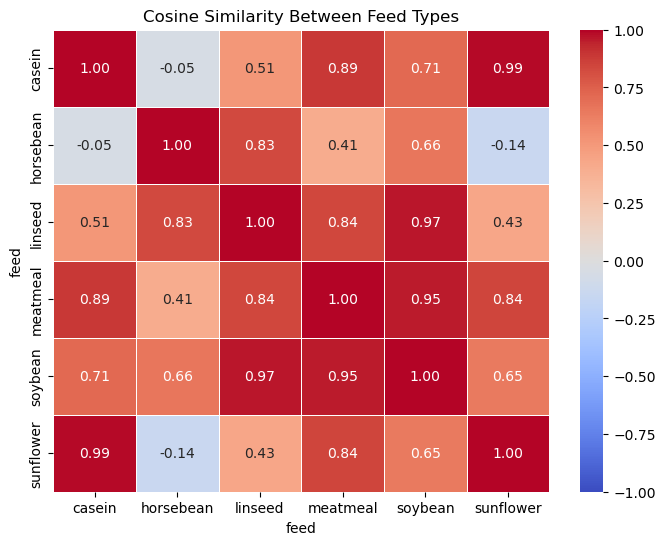

In [19]:
#Visualizing the Similarity Matrix 

plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Cosine Similarity Between Feed Types')
plt.show()

The heatmap shows strong similarity clusters: 

Linseed, Soybean, and Meatmeal are all highly similar to each other, and casein and sunflower are highly similar to each other, while horsebean stands apart from most other feeds , consistent with it being the clear low-performing outlier in the boxplot from Step 1.

## 8.0 Build a Recommendation Function

This function turns the similarity matrix into an actual recommendation: 
given a feed type, it returns the most similar alternatives, ranked highest to lowest.

In [20]:
def recommend_similar_feeds(target_feed, sim_df, top_n=3):
    similarities = sim_df[target_feed].drop(target_feed).sort_values(ascending=False)
    return similarities.head(top_n)

# An example:
recommend_similar_feeds('horsebean', sim_df)

feed
linseed     0.830921
soybean     0.661111
meatmeal    0.405563
Name: horsebean, dtype: float64

## 9.0 Key Insights
### Performance Patterns
High Performers: Sunflower and casein produce similar weight outcomes

Medium Performers: Linseed, soybean, and meatmeal form a cluster

Low Performer: Horsebean is distinctly different and underperforming



## 10.0 Recommendations and conclusion
If casein is unavailable, sunflower is the best alternative

If linseed is unavailable, soybean is very similar

When stocking priotize Sunflower and casein and have linseed and soybean as backups

### The Following is the feed recomendation table  

In [21]:
# Feed recommendation data
recommendations = {
    'Primary Feed': [
        'casein',
        'horsebean',
        'linseed',
        'meatmeal',
        'soybean',
        'sunflower'
    ],
    'Best Alternative': [
        'sunflower',
        'linseed',
        'soybean',
        'soybean',
        'linseed',
        'casein'
    ],
    'Best Score': [
        0.99,
        0.83,
        0.97,
        0.95,
        0.97,
        0.99
    ],
    'Second Alternative': [
        'meatmeal',
        'soybean',
        'meatmeal',
        'casein',
        'meatmeal',
        'meatmeal'
    ],
    'Second Score': [
        0.89,
        0.66,
        0.84,
        0.89,
        0.95,
        0.85
    ],
    'Third Alternative': [
        'soybean',
        'meatmeal',
        'horsebean',
        'linseed',
        'casein',
        'soybean'
    ],
    'Third Score': [
        0.71,
        0.41,
        0.83,
        0.84,
        0.71,
        0.65
    ]
}

# Create DataFrame
recommendation_table = pd.DataFrame(recommendations)

# Display table
recommendation_table

,Primary Feed,Best Alternative,Best Score,Second Alternative,Second Score,Third Alternative,Third Score
0,casein,sunflower,0.99,meatmeal,0.89,soybean,0.71
1,horsebean,linseed,0.83,soybean,0.66,meatmeal,0.41
2,linseed,soybean,0.97,meatmeal,0.84,horsebean,0.83
3,meatmeal,soybean,0.95,casein,0.89,linseed,0.84
4,soybean,linseed,0.97,meatmeal,0.95,casein,0.71
5,sunflower,casein,0.99,meatmeal,0.85,soybean,0.65


The project demonstrates how historical chicken-weight data can be transformed into a data-driven feed recommendation system.By combining feed performance profiling, PCA, and cosine similarity, the system can identify feed types with similar observed performance profiles and provide alternative recommendations.However, the dataset had no enough data to make a complete pourty farming recommendation system to be used by all the stakeholders

In conclusion ,The Chick Weight Feed Recommendation System is complete and ready for deployment.